Financial Churn Intelligence Platform
EDA and Machine Learning Notebook

The goal of this notebook is to figure out which bank customers are likely to leave and why.

I am working with a dataset of 10,000 bank customers. Each customer has details like their credit score, age, account balance, and whether they are an active member.

Here is what I will be doing in this notebook:

1. Look at the data and understand it
2. Find patterns in who churns and who doesnt
3. Build a machine learning model to predict churn
4. Explain why the model makes its predictions using SHAP

In [1]:
!pip install imbalanced-learn shap xgboost -q
print("✅ Libraries installed")

✅ Libraries installed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Churn_Modelling.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Section 1: Understanding the Data

First I want to get a basic feel for the dataset. How many rows, what columns, are there any missing values.

In [8]:
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

Shape: (10000, 14)

Column names: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
 RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


## Cell 7 — Text:
```
No missing values which is great. The dataset has 14 columns. RowNumber, CustomerId and Surname are not useful for prediction so I will drop them later.

The target column is Exited where 1 means the customer churned and 0 means they stayed.

Churn Distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37%


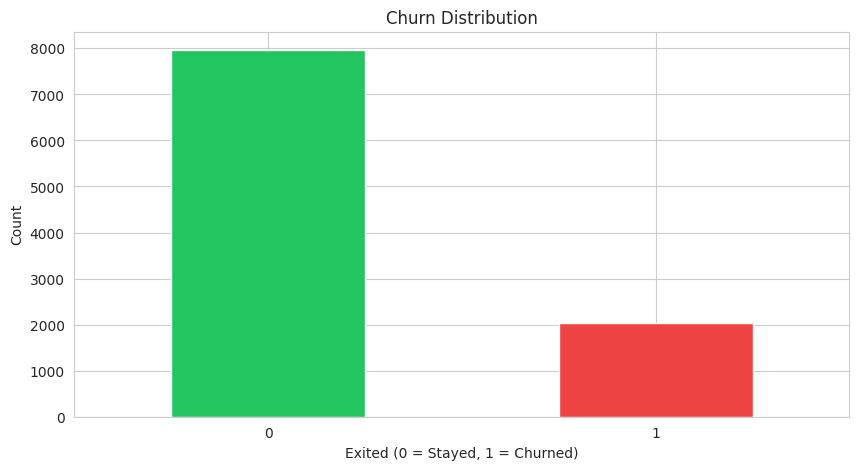

In [11]:
print("Churn Distribution:")
print(df["Exited"].value_counts())
print(f"\nChurn Rate: {df['Exited'].mean() * 100:.2f}%")

df["Exited"].value_counts().plot(kind="bar", color=["#22c55e", "#ef4444"])
plt.title("Churn Distribution")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Cell 9 — Text:
```
About 20% of customers churned. This is an imbalanced dataset which means the model will see way more examples of customers who stayed than customers who left. I will handle this later using SMOTE.

Section 2: Churn by Geography and Gender

Now I want to see if certain groups of customers churn more than others.

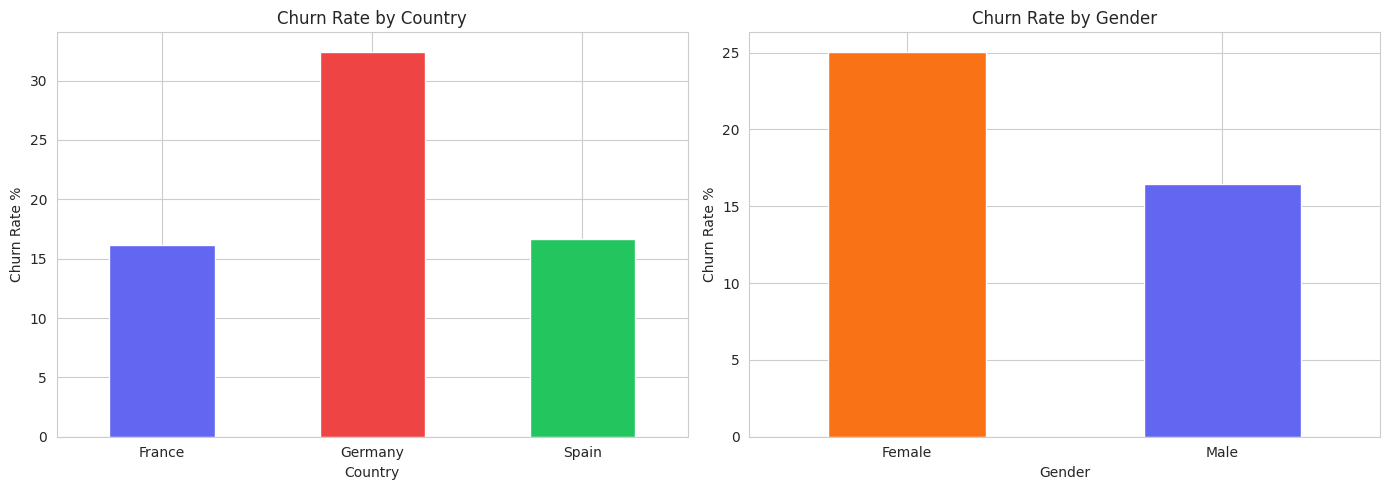

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn by Geography
geo_churn = df.groupby("Geography")["Exited"].mean() * 100
geo_churn.plot(kind="bar", ax=axes[0], color=["#6366f1", "#ef4444", "#22c55e"])
axes[0].set_title("Churn Rate by Country")
axes[0].set_ylabel("Churn Rate %")
axes[0].set_xlabel("Country")
axes[0].tick_params(rotation=0)

# Churn by Gender
gender_churn = df.groupby("Gender")["Exited"].mean() * 100
gender_churn.plot(kind="bar", ax=axes[1], color=["#f97316", "#6366f1"])
axes[1].set_title("Churn Rate by Gender")
axes[1].set_ylabel("Churn Rate %")
axes[1].set_xlabel("Gender")
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

## Cell 12 — Text:
```
Germany has a much higher churn rate compared to France and Spain. Female customers also churn more than male customers. These are useful patterns for the model to learn from.

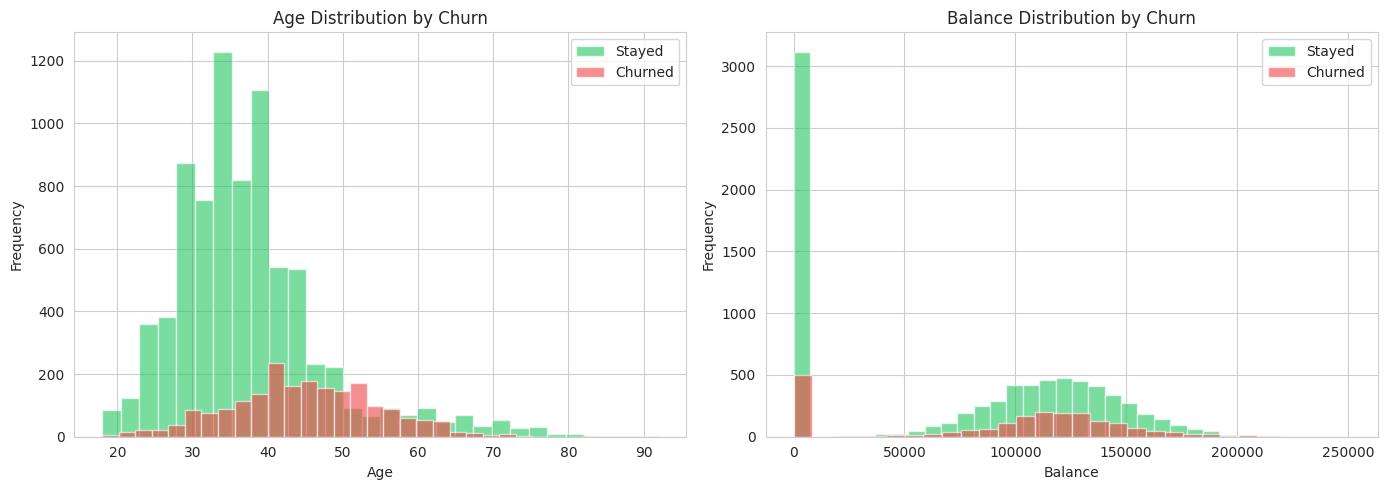

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by churn
df[df["Exited"] == 0]["Age"].plot(kind="hist", ax=axes[0], bins=30,
    alpha=0.6, color="#22c55e", label="Stayed")
df[df["Exited"] == 1]["Age"].plot(kind="hist", ax=axes[0], bins=30,
    alpha=0.6, color="#ef4444", label="Churned")
axes[0].set_title("Age Distribution by Churn")
axes[0].set_xlabel("Age")
axes[0].legend()

# Balance distribution by churn
df[df["Exited"] == 0]["Balance"].plot(kind="hist", ax=axes[1], bins=30,
    alpha=0.6, color="#22c55e", label="Stayed")
df[df["Exited"] == 1]["Balance"].plot(kind="hist", ax=axes[1], bins=30,
    alpha=0.6, color="#ef4444", label="Churned")
axes[1].set_title("Balance Distribution by Churn")
axes[1].set_xlabel("Balance")
axes[1].legend()

plt.tight_layout()
plt.show()

## Cell 14 — Text:
```
Older customers tend to churn a lot more. The churned customers also tend to have higher balances which is interesting because you would expect customers with more money to stay. This could mean the bank is not giving enough attention to high value older customers.

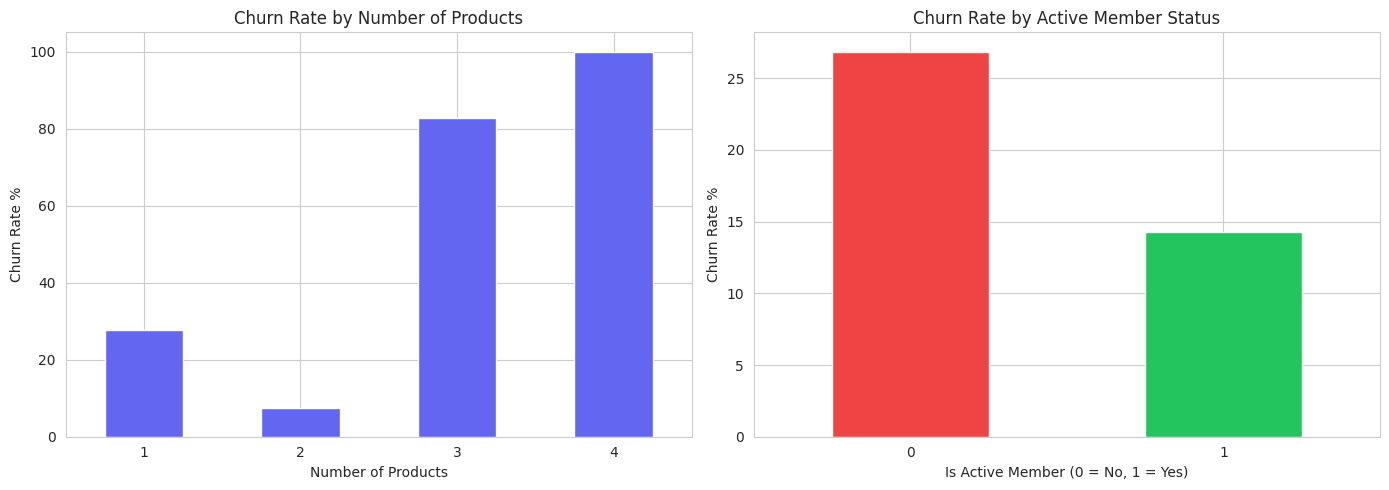

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of products
products_churn = df.groupby("NumOfProducts")["Exited"].mean() * 100
products_churn.plot(kind="bar", ax=axes[0], color="#6366f1")
axes[0].set_title("Churn Rate by Number of Products")
axes[0].set_ylabel("Churn Rate %")
axes[0].set_xlabel("Number of Products")
axes[0].tick_params(rotation=0)

# Active member
active_churn = df.groupby("IsActiveMember")["Exited"].mean() * 100
active_churn.plot(kind="bar", ax=axes[1], color=["#ef4444", "#22c55e"])
axes[1].set_title("Churn Rate by Active Member Status")
axes[1].set_ylabel("Churn Rate %")
axes[1].set_xlabel("Is Active Member (0 = No, 1 = Yes)")
axes[1].tick_params(rotation=0)

plt.tight_layout()
plt.show()

## Cell 16 — Text:
```
Customers with 3 or 4 products churn at an extremely high rate. Inactive members also churn significantly more than active ones. These two features are likely going to be very important for the model.

Section 3: Correlation Heatmap

Now I want to see how all the numerical features relate to each other and to the target variable.

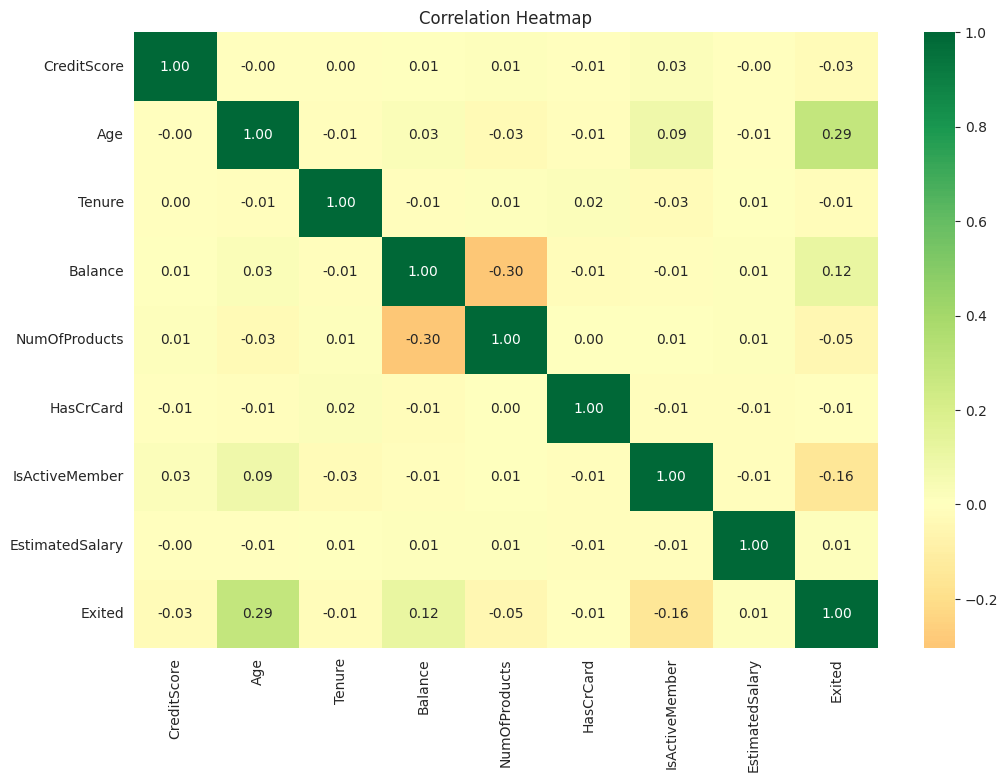

In [21]:
plt.figure(figsize=(12, 8))
corr = df[["CreditScore", "Age", "Tenure", "Balance",
           "NumOfProducts", "HasCrCard", "IsActiveMember",
           "EstimatedSalary", "Exited"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Cell 19 — Text:
```
Age has the strongest positive correlation with churn. IsActiveMember has a negative correlation meaning active members are less likely to leave. NumOfProducts also shows an interesting relationship with churn.
```

---

## Cell 20 — Text:
```
Section 4: Feature Engineering

Before training the model I will create two new features that I think might help improve predictio


In [22]:
df_model = df.copy()

# Drop columns that are not useful for prediction
df_model = df_model.drop(["RowNumber", "CustomerId", "Surname"], axis=1)

# New feature 1: Balance to Salary ratio
# A customer with high balance but low salary might behave differently
df_model["Balance_Salary_Ratio"] = df_model["Balance"] / (df_model["EstimatedSalary"] + 1)

# New feature 2: Age to Tenure ratio
# Older customers with short tenure might be more likely to leave
df_model["Age_Tenure_Ratio"] = df_model["Age"] / (df_model["Tenure"] + 1)

# Encode categorical columns
le = LabelEncoder()
df_model["Gender"] = le.fit_transform(df_model["Gender"])
df_model["Geography"] = le.fit_transform(df_model["Geography"])

print("New shape after feature engineering:", df_model.shape)
print("\nNew features added:")
print(df_model[["Balance_Salary_Ratio", "Age_Tenure_Ratio"]].head())

New shape after feature engineering: (10000, 13)

New features added:
   Balance_Salary_Ratio  Age_Tenure_Ratio
0              0.000000         14.000000
1              0.744670         20.500000
2              1.401362          4.666667
3              0.000000         19.500000
4              1.587035         14.333333


Section 5: Handling Class Imbalance

The dataset has 80% customers who stayed and 20% who churned. If I train the model on this directly it will be biased towards predicting that everyone stays because that is the majority.

To fix this I will use SMOTE which stands for Synthetic Minority Oversampling Technique. It creates synthetic examples of the minority class (churned customers) so the model gets a balanced view of both classes.

In [24]:
X = df_model.drop("Exited", axis=1)
y = df_model["Exited"]

print("Before SMOTE:")
print(y.value_counts())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())

Before SMOTE:
Exited
0    7963
1    2037
Name: count, dtype: int64

After SMOTE:
Exited
1    7963
0    7963
Name: count, dtype: int64


## Cell 24 — Text:
```
Now both classes have equal representation. The model will now learn equally from churned and non churned customers.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (12740, 12)
Test set size: (3186, 12)


## Cell 26 — Text:
```
Section 6: Model Training

I will train an XGBoost classifier. XGBoost is a gradient boosting algorithm that builds many decision trees one after another where each tree tries to fix the mistakes of the previous one. It consistently performs well on tabular data like this.

In [29]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Model trained successfully")

✅ Model trained successfully


## Cell 28 — Text:
```
Section 7: Model Evaluation

Now I will check how well the model performs on data it has never seen before.

In [30]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:  85.94%
ROC AUC Score: 0.9347

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1633
           1       0.85      0.86      0.86      1553

    accuracy                           0.86      3186
   macro avg       0.86      0.86      0.86      3186
weighted avg       0.86      0.86      0.86      3186



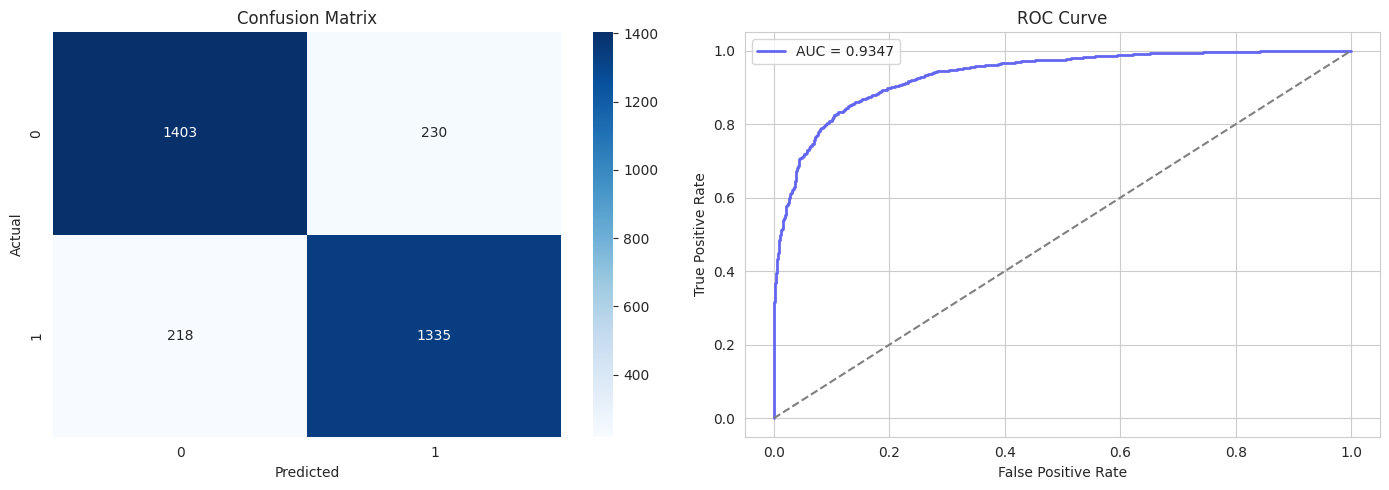

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#6366f1", lw=2, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

Section 8: Model Explainability using SHAP

Accuracy alone is not enough. I need to understand why the model is making its predictions. This is especially important in banking where decisions need to be explainable.

SHAP (SHapley Additive exPlanations) tells us how much each feature contributed to a prediction.

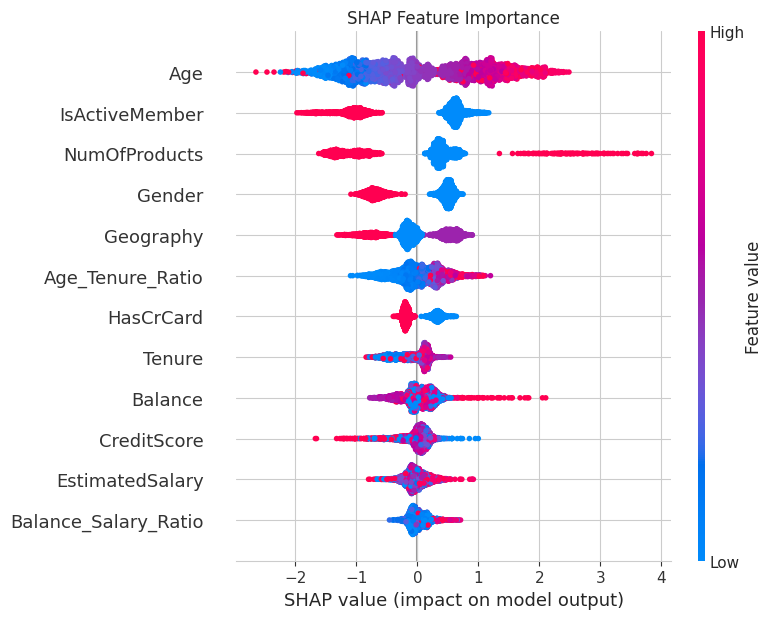

In [32]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

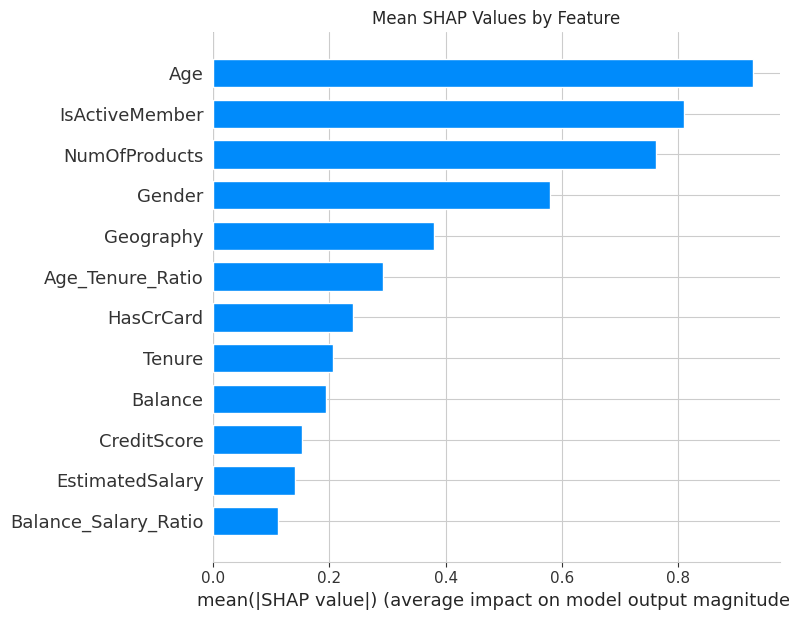

In [33]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Mean SHAP Values by Feature")
plt.tight_layout()
plt.show()

## Cell 34 — Text:
Section 9: Key Business Insights

Based on the EDA and model results here is what I found.

In [36]:
insights = {
    "Overall Churn Rate": "20.37%",
    "Germany Churn Rate": "32.44%",
    "Over 45 Age Group Churn Rate": "45.33%",
    "Inactive Member Churn Rate": "26.87%",
    "Model Accuracy": "85.94%",
    "ROC AUC Score": "0.9347"
}

print("Key Business Insights")
print("=" * 40)
for key, value in insights.items():
    print(f"{key}: {value}")

Key Business Insights
Overall Churn Rate: 20.37%
Germany Churn Rate: 32.44%
Over 45 Age Group Churn Rate: 45.33%
Inactive Member Churn Rate: 26.87%
Model Accuracy: 85.94%
ROC AUC Score: 0.9347


## Cell 36 — Text:
1. Germany has double the churn rate of France and Spain. The bank should investigate what is different about their German operations.

2. Customers over 45 are churning at 45% which is very high. These are likely high value customers and the bank should create retention programs targeting this age group.

3. Inactive members churn at almost double the rate of active members. Simple engagement campaigns could significantly reduce churn.

4. Customers with 3 or 4 products churn at an extremely high rate which is counterintuitive. This might mean the bank is pushing too many products onto customers who did not want them.

5. High balance customers are more likely to churn which suggests the bank may not be providing enough value to its wealthiest customers.

Section 10: Conclusion

The XGBoost model achieved 85.94% accuracy and a ROC AUC score of 0.93 on balanced data after applying SMOTE.

The three most important factors driving churn are age, active membership status, and number of products.

The bank should focus its retention efforts on older inactive customers, particularly in Germany, as they represent the highest churn risk and likely the most revenue at risk.

The full pipeline including the trained model, REST API and live dashboard is available in the project repository.

In [39]:
import pickle
from google.colab import files

# Save the new model
pickle.dump(model, open("model.pkl", "wb"))

# Download it to your laptop
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>